In [40]:
import pandas as pd

covid = pd.read_csv("../data/covid.csv")

india = covid[covid['location'] == 'India'][['date', 'new_cases']]
india['date'] = pd.to_datetime(india['date'])

print(india.head())

             date  new_cases
173549 2020-01-05        0.0
173550 2020-01-06        0.0
173551 2020-01-07        0.0
173552 2020-01-08        0.0
173553 2020-01-09        0.0


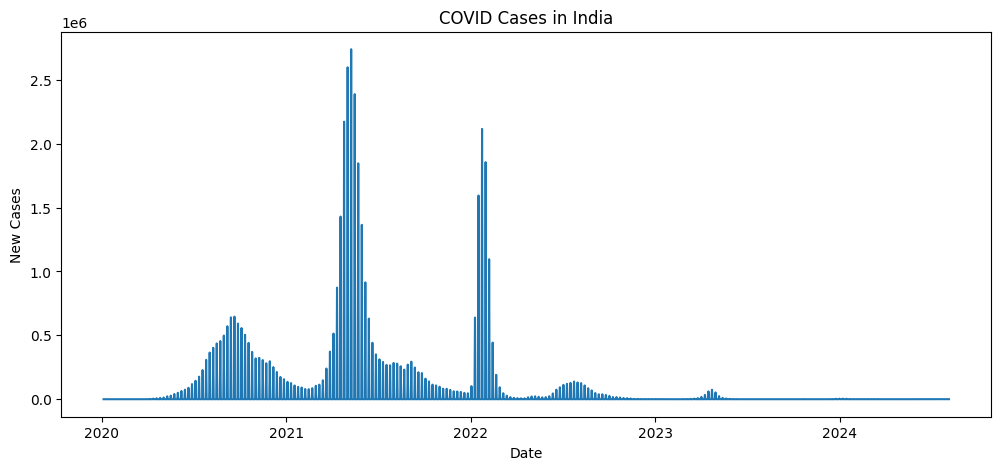

In [41]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))
plt.plot(india['date'], india['new_cases'])
plt.title("COVID Cases in India")
plt.xlabel("Date")
plt.ylabel("New Cases")
plt.show()

In [42]:
india = india.dropna(subset=['new_cases'])


india['lag_1'] = india['new_cases'].shift(1)
india['lag_7'] = india['new_cases'].shift(7)
india['lag_14'] = india['new_cases'].shift(14)
india['rolling_avg'] = india['new_cases'].rolling(7).mean()


india = india.dropna()

print(india.shape)

(1660, 6)


In [43]:
X = india[['lag_1', 'lag_7','lag_14', 'rolling_avg']]
y = india['new_cases']

In [44]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, shuffle=False
)

print("Train size:", len(X_train))
print("Test size:", len(X_test))

Train size: 1328
Test size: 332


In [45]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [46]:
pred = model.predict(X_test)

In [47]:
from sklearn.metrics import mean_absolute_error

print("MAE:", mean_absolute_error(y_test, pred))

MAE: 2199.190638956494


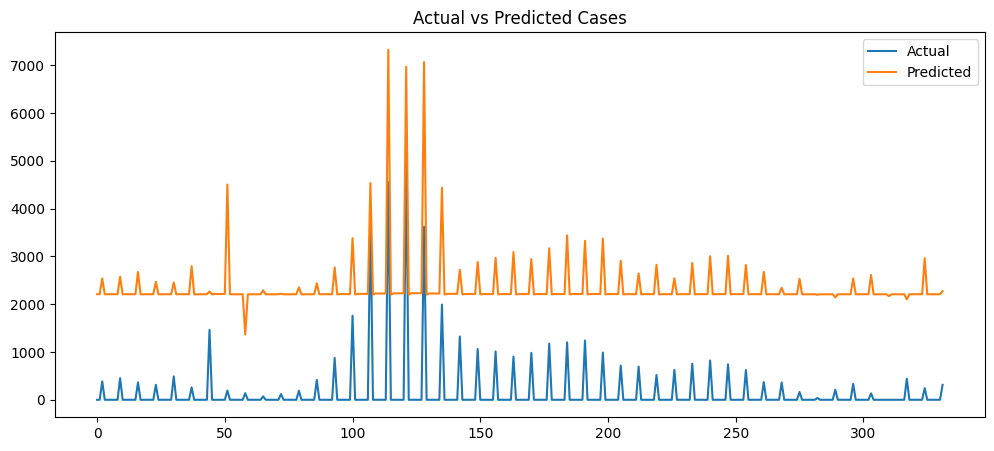

In [48]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))
plt.plot(y_test.values, label="Actual")
plt.plot(pred, label="Predicted")
plt.legend()
plt.title("Actual vs Predicted Cases")
plt.show()

In [49]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(n_estimators=100)
rf.fit(X_train, y_train)

pred_rf = rf.predict(X_test)

In [50]:
print("RF MAE:", mean_absolute_error(y_test, pred_rf))

RF MAE: 19.797948199725308


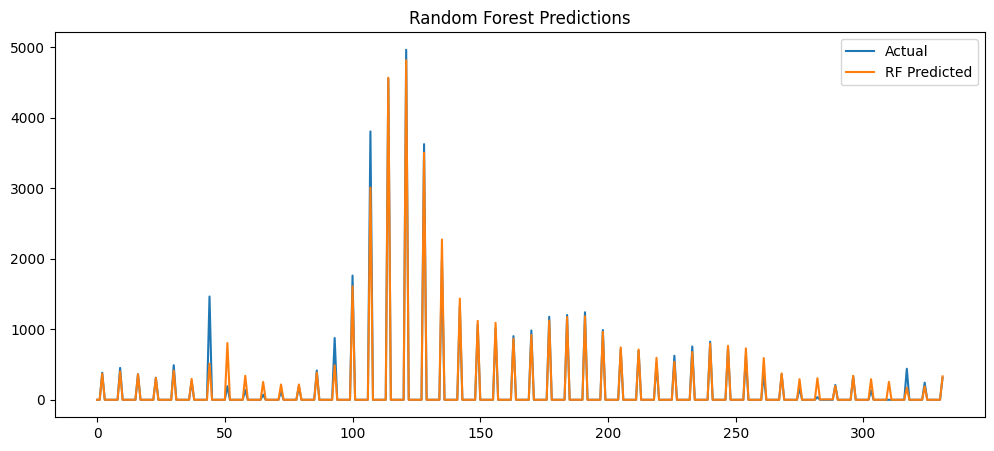

In [51]:
plt.figure(figsize=(12,5))
plt.plot(y_test.values, label="Actual")
plt.plot(pred_rf, label="RF Predicted")
plt.legend()
plt.title("Random Forest Predictions")
plt.show()

In [52]:
mobility = pd.read_csv("../data/mobility.csv")
mobility_india = mobility[mobility['country_region'] == 'India']

C:\Users\dhruv\AppData\Local\Temp\ipykernel_17172\2139732782.py:1: DtypeWarning: Columns (0: sub_region_2, 1: metro_area, 2: iso_3166_2_code) have mixed types. Specify dtype option on import or set low_memory=False.
  mobility = pd.read_csv("../data/mobility.csv")


In [54]:
mobility_india = mobility_india[['date', 
    'retail_and_recreation_percent_change_from_baseline']]

In [55]:
mobility_india['date'] = pd.to_datetime(mobility_india['date'])

In [56]:
mobility_india.head()

,date,retail_and_recreation_percent_change_from_baseline
5028430,2020-02-15,1.0
5028431,2020-02-16,2.0
5028432,2020-02-17,-1.0
5028433,2020-02-18,0.0
5028434,2020-02-19,0.0


In [57]:
merged = pd.merge(india, mobility_india, on='date')

In [58]:
X = merged[['lag_1', 'lag_7', 'lag_14', 'rolling_avg',
            'retail_and_recreation_percent_change_from_baseline']]

y = merged['new_cases']

In [59]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, shuffle=False
)

from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(n_estimators=100)
rf.fit(X_train, y_train)

pred = rf.predict(X_test)

from sklearn.metrics import mean_absolute_error
print("MAE:", mean_absolute_error(y_test, pred))

MAE: 586.1813358581776


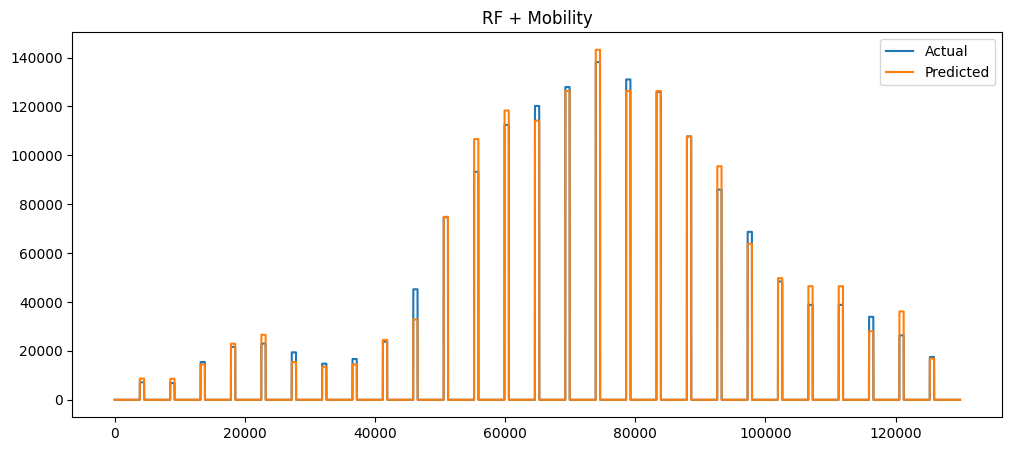

In [60]:

plt.figure(figsize=(12,5))
plt.plot(y_test.values, label="Actual")
plt.plot(pred, label="Predicted")
plt.legend()
plt.title("RF + Mobility")
plt.show()

In [61]:
pip install xgboost


   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
    --------------------------------------- 1.8/101.7 MB 8.4 MB/s eta 0:00:12
   - -------------------------------------- 3.7/101.7 MB 8.5 MB/s eta 0:00:12
   -- ------------------------------------- 6.0/101.7 MB 9.3 MB/s eta 0:00:11
   --- ------------------------------------ 8.7/101.7 MB 9.9 MB/s eta 0:00:10
   --- ------------------------------------ 10.0/101.7 MB 10.2 MB/s eta 0:00:10
   --- ------------------------------------ 10.0/101.7 MB 10.2 MB/s eta 0:00:10
   ---- ----------------------------------- 10.2/101.7 MB 7.4 MB/s eta 0:00:13
   ---- ----------------------------------- 10.2/101.7 MB 7.4 MB/s eta 0:00:13
   ---- ----------------------------------- 10.2/101.7 MB 7.4 MB/s eta 0:00:13
   ---- ----------------------------------- 10.2/101.7 MB 7.4 MB/s eta 0:00:13
   ---- ----------------------------------- 10.2/101.7 MB 7.4 MB/s eta

In [62]:
from xgboost import XGBRegressor

xgb = XGBRegressor(n_estimators=100, learning_rate=0.1)
xgb.fit(X_train, y_train)

pred_xgb = xgb.predict(X_test)

In [63]:
print("XGB MAE:", mean_absolute_error(y_test, pred_xgb))

XGB MAE: 501.89721264177666


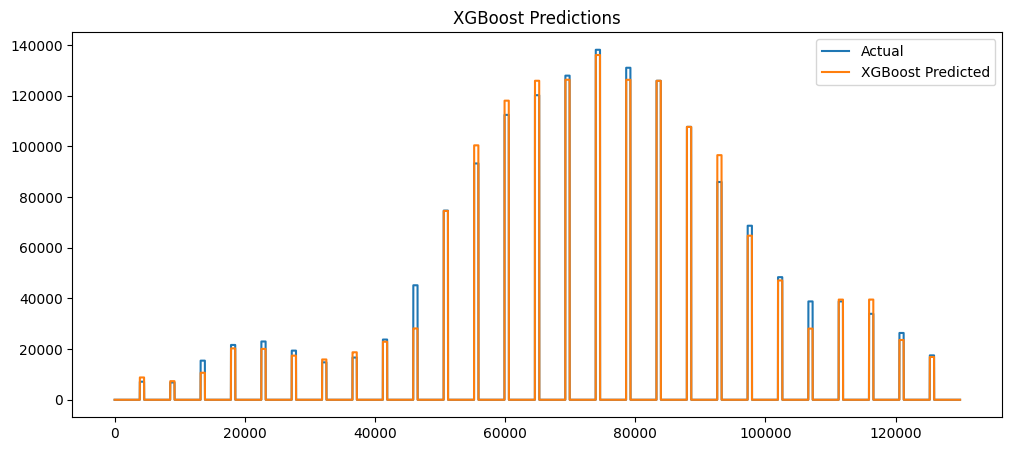

In [64]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))
plt.plot(y_test.values, label="Actual")
plt.plot(pred_xgb, label="XGBoost Predicted")
plt.legend()
plt.title("XGBoost Predictions")
plt.show()

In [65]:
merged['mobility_lag_7'] = merged['retail_and_recreation_percent_change_from_baseline'].shift(7)

In [66]:
merged = merged.dropna()

In [67]:
X = merged[['lag_1', 'lag_7', 'lag_14', 'rolling_avg', 'mobility_lag_7']]
y = merged['new_cases']

In [68]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, shuffle=False
)

from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(n_estimators=100)
rf.fit(X_train, y_train)

pred = rf.predict(X_test)

from sklearn.metrics import mean_absolute_error
print("MAE:", mean_absolute_error(y_test, pred))

MAE: 639.9397129482195


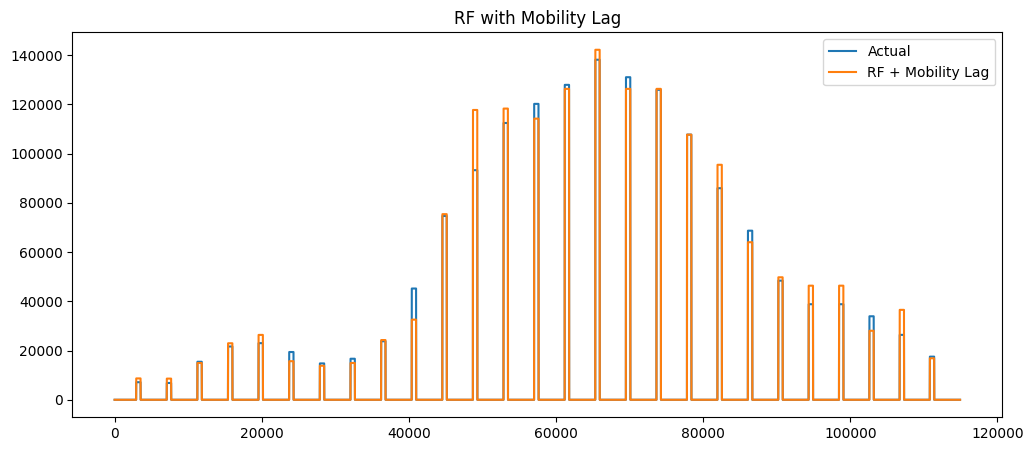

In [69]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))
plt.plot(y_test.values, label="Actual")
plt.plot(pred, label="RF + Mobility Lag")
plt.legend()
plt.title("RF with Mobility Lag")
plt.show()